c:\Users\PBarkema\OneDrive - University College London\Documents\PhD\BayesianLearning\optlearner-master\optlearner.py:132: SyntaxWarning: invalid escape sequence '\h'
  p_ax.set_ylabel("$\hat p$", size=16)
c:\Users\PBarkema\OneDrive - University College London\Documents\PhD\BayesianLearning\optlearner-master\optlearner.py:136: SyntaxWarning: invalid escape sequence '\h'
  I_ax.set_ylabel("$\hat U$", size=16)
c:\Users\PBarkema\OneDrive - University College London\Documents\PhD\BayesianLearning\optlearner-master\optlearner.py:305: SyntaxWarning: invalid escape sequence '\h'
  p_ax.set_ylabel("$\hat p$", size=16)
c:\Users\PBarkema\OneDrive - University College London\Documents\PhD\BayesianLearning\optlearner-master\optlearner.py:309: SyntaxWarning: invalid escape sequence '\h'
  I_ax.set_ylabel("$\hat I$", size=16)
c:\Users\PBarkema\OneDrive - University College London\Documents\PhD\BayesianLearning\optlearner-master\optlearner.py:313: SyntaxWarning: invalid escape sequence '\h'
  k_ax.se

900 μs ± 231 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


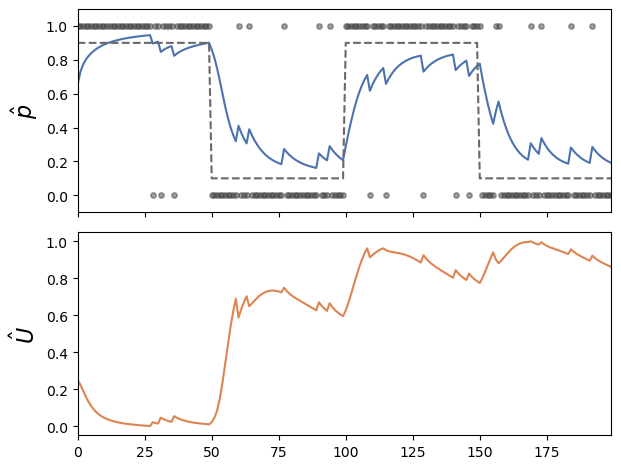

In [ ]:
from __future__ import division
import numpy as np
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import optlearner
# learner = optlearner.ProbabilityLearner()
# p_grid = learner.p_grid
# I_grid = learner.I_grid
# %timeit learner.fit([0])

learner = optlearner.ProbabilityLearner()

static_p = np.concatenate( [np.ones(50)* 0.9, np.ones(50)*0.1, np.ones(50)*0.9, np.ones(50)*0.1])
#static_p = np.ones(100)
# static_p[1:500] = 1.0
# static_p[500:750] = 0.0
# static_p[750:1000] = 0.5
static_y = stats.binom.rvs(1, static_p)
# static_y = np.concatenate([
#     np.random.binomial(1, 0.9, 50),
#     np.random.binomial(1, 0.1, 50),
#     np.random.binomial(1, 0.9, 50),
#     np.random.binomial(1, 0.1, 50)
# ])
learner.reset()
learner.fit(static_y)
learner.plot_history(ground_truth=static_p)


Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.


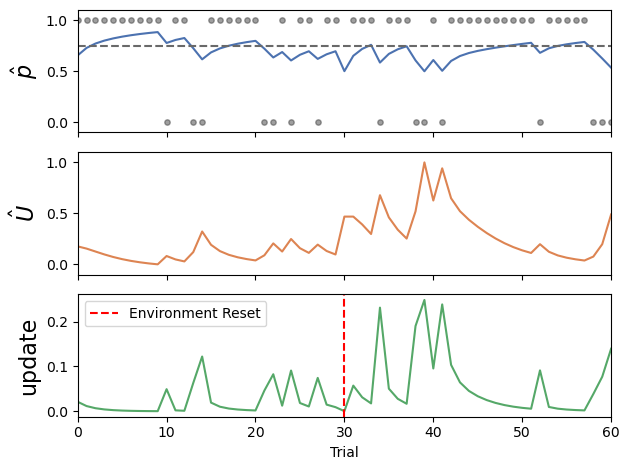

In [4]:
# Run 2 blocks of trials
from importlib import reload
reload(opt)

# Initialize
learner = opt.ProbabilityLearner()

# Generate Data: 
# Two environments with .75 predictive accuracy
block_size = 30
force_reset_point = block_size
force_reset_p_trials = 20
p= 0.75
data_part1 = np.random.binomial(1, p, block_size)
#data_env_reset = np.random.binomial(1, 0.5, force_reset_p_trials)
data_part2 = np.random.binomial(1, p, block_size)


learner.fit(data_part1)

print("Resetting Environment...")
learner.force_reset_new_tone() 
# Manual plot update

current_p_dist = learner.pI.sum(axis=1) 
current_I_dist = learner.pI.sum(axis=0)

p_hat_reset = np.sum(current_p_dist * learner.p_grid)
I_hat_reset = np.sum(current_I_dist * learner.I_grid)

# 2. Append to history
# We append these values directly to the internal lists
learner._p_hats.append(p_hat_reset)
learner._I_hats.append(I_hat_reset)
learner._data.append(np.nan) # NaN ensures no dot is drawn for this fake trial

learner.fit(data_part2)

learner.plot_history(ground_truth=p, y=data_part1.tolist() + [0.5] + data_part2.tolist() )
plt.axvline(x=force_reset_point, color='r', linestyle='--', label='Environment Reset')
plt.legend()
plt.show()


Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.


In [1]:
from __future__ import division
import numpy as np
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import optlearner as opt
from importlib import reload


# Simulate multiple blocks of data with environment resets and collect metrics
def simulate_data(nBlocks = 4):
    from importlib import reload
    reload(opt)
    
    block_size = 30
    p= 0.75
    force_reset_point = block_size
    #U_hats_history = np.zeros((nBlocks, block_size *2 +1)) * np.nan
    p_hat_history=np.zeros((nBlocks, block_size *2 +1)) * np.nan
    U_hat_history=np.zeros((nBlocks, block_size *2 +1)) * np.nan
    PE_Uhat_history = np.zeros((nBlocks, block_size *2 +1)) * np.nan
    P_I_history = np.zeros((nBlocks, block_size *2 +1)) * np.nan
    invalid_indices = []#np.zeros((nBlocks, block_size *2 +1)) * np.nan
    valid_indices = []
    for iBlock in range(nBlocks):
        # Initialize
        learner = opt.ProbabilityLearner()
        # Generate Data: 
        # Two environments with .75 predictive accuracy
        np.random.seed(iBlock)
    
        data_part1 = np.random.binomial(1, p, block_size)
        #data_env_reset = np.random.binomial(1, 0.5, force_reset_p_trials)
        np.random.seed(iBlock)
        data_part2 = np.random.binomial(1, p, block_size)

        learner.fit(data_part1)

        print("Resetting Environment...")
        learner.force_reset_new_tone() 
        # Manual plot update

        current_p_dist = learner.pI.sum(axis=1) 
        current_I_dist = learner.pI.sum(axis=0)

        p_hat_reset = np.sum(current_p_dist * learner.p_grid)
        I_hat_reset = np.sum(current_I_dist * learner.I_grid)

        # 2. Append to history
        # We append these values directly to the internal lists
        learner._p_hats.append(p_hat_reset)
        learner._I_hats.append(I_hat_reset)
        learner._data.append(np.nan) # NaN ensures no dot is drawn for this fake trial

        learner.fit(data_part2)
        # learner.plot_history(ground_truth=p, y=data_part1.tolist() + [0.5] + data_part2.tolist() )
        # plt.axvline(x=force_reset_point, color='r', linestyle='--', label='Environment Reset')
        # plt.legend()
        # plt.show()
        y=data_part1.tolist() + [np.random.rand()] + data_part2.tolist()
        # Get metrix for this block

        # p_hats, U_hats, PE_Uhats = learner.get_metrics(y=y)

        # DEBUG manually get_metrics
        I_hats = learner.I_hats
        p_hats = learner.p_hats
        #I_hats_invalid = np.where(np.array(learner._data) == 1 & np.array(ground_truth) == 0 || np.array(learner._data) == 0 & np.array(ground_truth) == 1)[0])
        # Convert to arrays once for readability and performance
        l_data = np.array(p_hats)
        gt_data = np.array(y)

        invalid_trials = np.where(
            (gt_data == 0) 
        )[0]

        valid_trials = np.where(
            (gt_data == 1) 
        )[0]
        #     valid_trials = np.where(
        #     ((gt_data == 1) & (l_data < 0.5)) |
        #     ((gt_data == 1) & (l_data > 0.5))
        # )[0]
        
        
        U_hats = [1/u for u in np.exp(I_hats)]
        U_hats_scaled = (U_hats - np.min(U_hats)) / (np.max(U_hats) - np.min(U_hats))
        U_hats = U_hats_scaled

        PE = (p_hats - y)**2

        # Calculation of PE ^ UU as combined uncertainty measure
        PE_Uhat = PE * U_hats


        P_I = p_hats * I_hats
        P_I_scaled = (P_I - np.min(P_I)) / (np.max(P_I) - np.min(P_I))
        P_I = P_I_scaled

        U_hats = U_hats_scaled
        #data_history[iBLock,:] = learner._data
        p_hat_history[iBlock,:] = p_hats
        U_hat_history[iBlock,:]= U_hats
        PE_Uhat_history[iBlock,:] = PE_Uhat
        P_I_history[iBlock,:] = P_I
        invalid_indices.append([invalid_trials])
        valid_indices.append([valid_trials])
        learner.reset()
    return p_hat_history, U_hat_history, PE_Uhat_history, P_I_history, invalid_indices, valid_indices, force_reset_point

# Get smoothed bounds for plotting
def get_smooth_bounds(mean_data, se_data, window):
    """Returns smoothed Mean, Upper (Mean+SE), and Lower (Mean-SE)"""
    upper = mean_data + se_data
    lower = mean_data - se_data
    
    # Smooth all three
    s_mean = pd.Series(mean_data).rolling(window=window, min_periods=1, center=True).mean().values
    s_upper = pd.Series(upper).rolling(window=window, min_periods=1, center=True).mean().values
    s_lower = pd.Series(lower).rolling(window=window, min_periods=1, center=True).mean().values
    
    return s_mean, s_upper, s_lower

# Scales mean and bounds. Fits scaler on mean, transforms bounds.
def scale_bounds(s_mean, s_upper, s_lower, fitted_scaler=None):
    """Scales mean and bounds. Fits scaler on mean, transforms bounds."""
    # Reshape for sklearn
    s_mean_r = s_mean.reshape(-1, 1)
    s_upper_r = s_upper.reshape(-1, 1)
    s_lower_r = s_lower.reshape(-1, 1)
    
    if fitted_scaler is None:
        fitted_scaler = MinMaxScaler()
        s_mean_scaled = fitted_scaler.fit_transform(s_mean_r).flatten()
    else:
        s_mean_scaled = fitted_scaler.transform(s_mean_r).flatten()
        
    s_upper_scaled = fitted_scaler.transform(s_upper_r).flatten()
    s_lower_scaled = fitted_scaler.transform(s_lower_r).flatten()
    
    return s_mean_scaled, s_upper_scaled, s_lower_scaled, fitted_scaler

In [2]:



def pool_data_across_blocks(PE_Uhat_history, P_I_history, invalid_indices, valid_indices, nBlocks):
    import numpy as np
    from collections import defaultdict

    # 1. Initialize dictionaries to map indices to lists of values
    #    We use lists so we can collect all values for an index and average them later.
    temp_invalid_PE_U = defaultdict(list)
    temp_invalid_P_I = defaultdict(list)
    temp_valid_PE_U = defaultdict(list)
    temp_valid_P_I = defaultdict(list)

    for iBlock in range(nBlocks):
        # Retrieve the metrics for this block
        # PE_Uhat_history is shape (nBlocks, trials)
        block_PE_U_values = PE_Uhat_history[iBlock]
        block_P_I_values = P_I_history[iBlock]
        
        # Retrieve the invalid indices for this block
        # Note: Preserving your logic accessing [0]
        block_invalid_indices = invalid_indices[iBlock][0]
        block_valid_indices = valid_indices[iBlock][0]
        
        # --- INVALID TRIALS ---
        for idx in block_invalid_indices:
            val = block_PE_U_values[idx]
            val2 = block_P_I_values[idx]
            
            # Append value to the list for this specific index
            temp_invalid_PE_U[idx].append(val)
            temp_invalid_P_I[idx].append(val2)

        # --- VALID TRIALS ---
        for idx in block_valid_indices:
            val = block_PE_U_values[idx]
            val2 = block_P_I_values[idx]
            
            # Append value to the list for this specific index
            temp_valid_PE_U[idx].append(val)
            temp_valid_P_I[idx].append(val2)

    # 2. Compute the averages and store them in the final list format
    #    Format: (index_number, average_value)
    pooled_data_invalid_PE_U = [(idx, np.mean(vals)) for idx, vals in sorted(temp_invalid_PE_U.items())]
    pooled_data_invalid_P_I  = [(idx, np.mean(vals)) for idx, vals in sorted(temp_invalid_P_I.items())]
    pooled_data_valid_PE_U   = [(idx, np.mean(vals)) for idx, vals in sorted(temp_valid_PE_U.items())]
    pooled_data_valid_P_I    = [(idx, np.mean(vals)) for idx, vals in sorted(temp_valid_P_I.items())]

    # 2. Sort the pooled data based on the trial index (the first item in the tuple)
    #    This ensures that an error at Trial 5 (from any block) comes before Trial 10
    pooled_data_invalid_PE_U.sort(key=lambda x: x[0])
    pooled_data_valid_PE_U.sort(key=lambda x: x[0])
    pooled_data_invalid_P_I.sort(key=lambda x: x[0])
    pooled_data_valid_P_I.sort(key=lambda x: x[0])


    # 3. Extract just the values into your final list
    PE_Uhat_invalid_combined = [x[1] for x in pooled_data_invalid_PE_U]
    PE_Uhat_invalid_indices= [x[0] for x in pooled_data_invalid_PE_U]

    PE_Uhat_valid_combined = [x[1] for x in pooled_data_valid_PE_U]
    PE_Uhat_valid_indices= [x[0] for x in pooled_data_valid_PE_U]

    # Optional: Convert to numpy array if needed for further math
    PE_Uhat_invalid_combined = np.array(PE_Uhat_invalid_combined)
    PE_Uhat_valid_combined = np.array(PE_Uhat_valid_combined)

    # 3. Extract just the values into your final list
    P_I_invalid_combined = [x[1] for x in pooled_data_invalid_P_I]
    P_I_invalid_indices= [x[0] for x in pooled_data_invalid_P_I]

    P_I_valid_combined = [x[1] for x in pooled_data_valid_P_I]
    P_I_valid_indices= [x[0] for x in pooled_data_valid_P_I]

    # Optional: Convert to numpy array if needed for further math
    P_I_invalid_combined = np.array(P_I_invalid_combined)
    P_I_invalid_combined = P_I_invalid_combined * -1 # Invert to match Peter's plots
    P_I_valid_combined = np.array(P_I_valid_combined)

    print(f"Combined {len(PE_Uhat_invalid_combined)} invalid trials from {nBlocks} blocks.")
    print("First 10 values:", PE_Uhat_invalid_combined[:10])
    return PE_Uhat_invalid_combined, P_I_invalid_combined, PE_Uhat_valid_combined, P_I_valid_combined, PE_Uhat_invalid_indices, P_I_invalid_indices, PE_Uhat_valid_indices, P_I_valid_indices

nBlocks = 4
p_hat_history, U_hat_history, PE_Uhat_history, P_I_history, invalid_indices, valid_indices, force_reset_point = simulate_data()
PE_Uhat_invalid_combined, P_I_invalid_combined, PE_Uhat_valid_combined, P_I_valid_combined, PE_Uhat_invalid_indices, P_I_invalid_indices, PE_Uhat_valid_indices, P_I_valid_indices = pool_data_across_blocks(PE_Uhat_history, P_I_history, invalid_indices, valid_indices, nBlocks)

Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Combined 36 invalid trials from 4 blocks.
First 10 values: [0.17878562 0.21208332 0.04804526 0.09995371 0.1080337  0.07384862
 0.03841184 0.11675171 0.06162536 0.1202371 ]


In [ ]:

nBlocks = 4
p_hat_history, U_hat_history, PE_Uhat_history, P_I_history, invalid_indices, valid_indices, force_reset_point = simulate_data()
PE_Uhat_invalid_combined, P_I_invalid_combined, PE_Uhat_valid_combined, P_I_valid_combined, PE_Uhat_invalid_indices, P_I_invalid_indices, PE_Uhat_valid_indices, P_I_valid_indices = pool_data_across_blocks(PE_Uhat_history, P_I_history, invalid_indices, valid_indices, nBlocks)
# --- 1. Setup & Calculations ---


Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Resetting Environment...
>> New Tone Detected: Beliefs Reset to Flat Prior.
Combined 36 invalid trials from 4 blocks.
First 10 values: [0.04525394 0.12460934 0.17377782 0.17027367 0.27564169 0.21409312
 0.13250972 0.09017215 0.13193747 0.09276908]


<>:132: SyntaxWarning: invalid escape sequence '\h'
<>:141: SyntaxWarning: invalid escape sequence '\h'
<>:132: SyntaxWarning: invalid escape sequence '\h'
<>:141: SyntaxWarning: invalid escape sequence '\h'
C:\Users\PBarkema\AppData\Local\Temp\ipykernel_7848\3255270408.py:132: SyntaxWarning: invalid escape sequence '\h'
  p_ax.set_title("$\hat v$", size=12)
C:\Users\PBarkema\AppData\Local\Temp\ipykernel_7848\3255270408.py:141: SyntaxWarning: invalid escape sequence '\h'
  I_ax.set_title("$\hat U$", size=12)


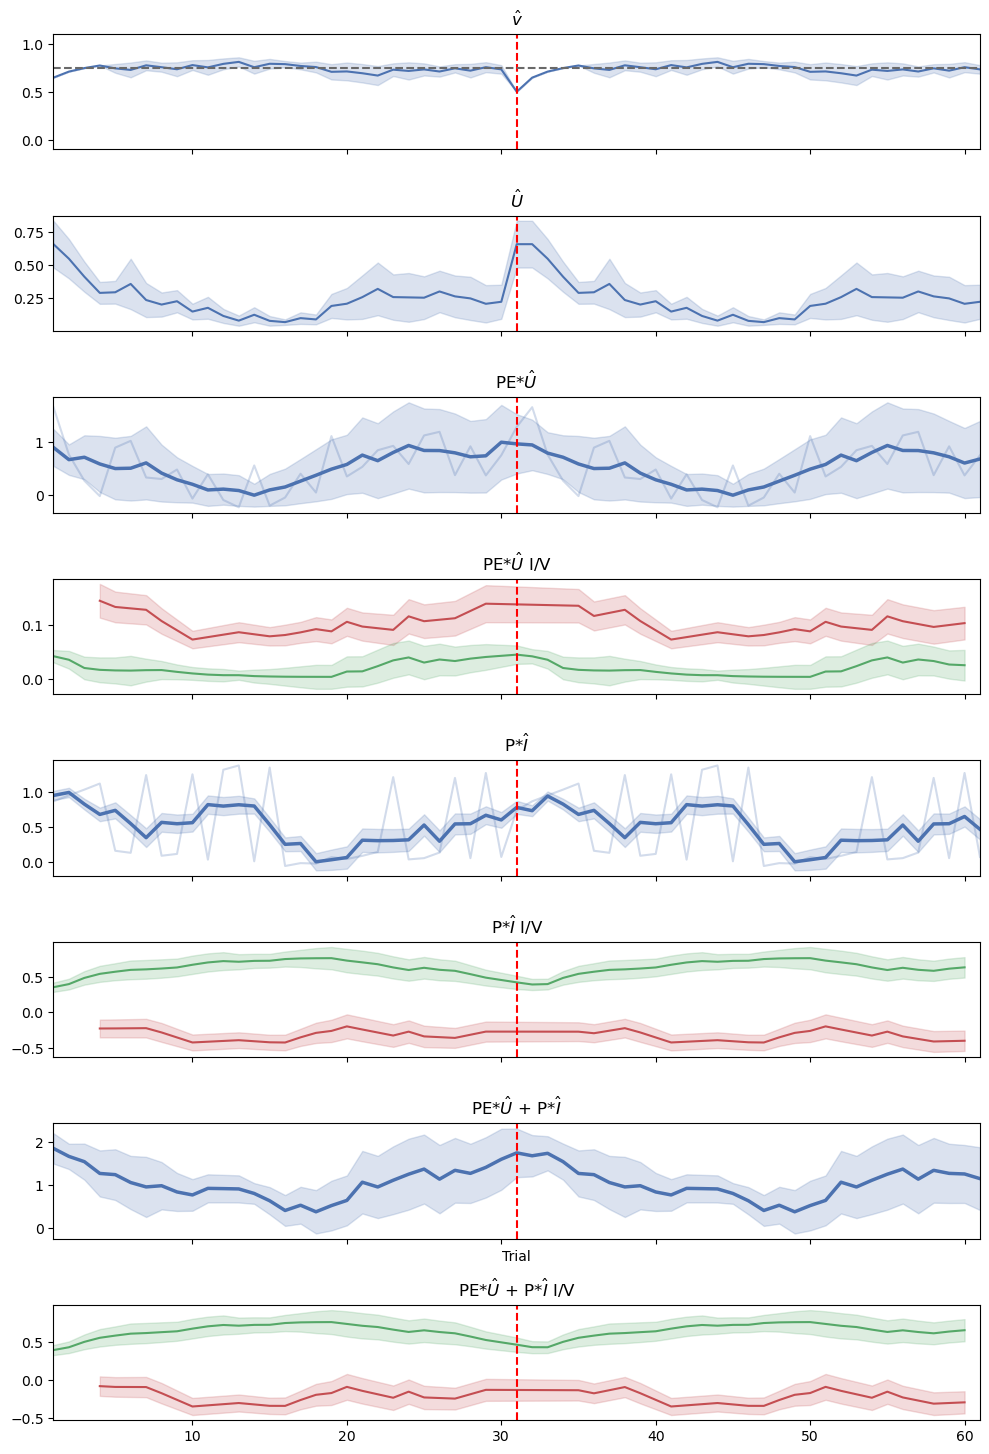

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
# Helper to get Standard Error (SE)
def get_se(history_data):
    # Standard Error = Std Dev / sqrt(N)
    return np.nanstd(history_data, axis=0) / np.sqrt(history_data.shape[0])

# Calculate Means
p_hats_mean = np.nanmean(p_hat_history, axis=0)
U_hats_mean = np.nanmean(U_hat_history, axis=0)
PE_Uhat_mean = np.nanmean(PE_Uhat_history, axis=0)
P_I_mean = np.nanmean(P_I_history, axis=0)
P_I_mean = np.array(P_I_mean)
P_I_mean[P_I_invalid_indices] = P_I_mean[P_I_invalid_indices] * -1

# Calculate SEs
p_se = get_se(p_hat_history)
U_se = get_se(U_hat_history)
PE_U_se = get_se(PE_Uhat_history)
P_I_se = get_se(P_I_history)

# Calculate Difference History for accurate SE of the difference (Plot 7)
# (Var(A-B) is better calculated from the raw difference history than derived from summary stats)
diff_history = PE_Uhat_history - P_I_history
diff_mean = np.nanmean(diff_history, axis=0)
diff_se = get_se(diff_history)

# Assign to your variables
p_hats = p_hats_mean
U_hats = U_hats_mean
PE_Uhats = PE_Uhat_mean

# Valid/Invalid Means (Assuming these are slices of the main data based on indices)
# If PE_Uhat_invalid_combined is just the sliced mean, we use the indices to slice the SE too.
PE_Uhats_invalid_mean = PE_Uhat_invalid_combined 
PE_Uhats_valid_mean = PE_Uhat_valid_combined
P_I_invalid_mean = P_I_invalid_combined
P_I_valid_mean = P_I_valid_combined

# Slice SEs for Valid/Invalid plots
PE_U_se_invalid = PE_U_se[PE_Uhat_invalid_indices]
PE_U_se_valid = PE_U_se[PE_Uhat_valid_indices]
P_I_se_invalid = P_I_se[P_I_invalid_indices]
P_I_se_valid = P_I_se[P_I_valid_indices]

# Difference Valid/Invalid SEs
diff_se_invalid = diff_se[P_I_invalid_indices] # Assuming indices align
diff_se_valid = diff_se[P_I_valid_indices]

ground_truth = 0.75
trials = np.arange(1, len(p_hats_mean)+1)
blue, orange, green, red = sns.color_palette("deep", n_colors=4)
xlim = trials.min(), trials.max()

# --- 2. Smoothing & Scaling Helpers ---

wdw = 3
scaler = MinMaxScaler()



# --- 3. Process Data for Plots ---

# A. PE * U (Plot 3)
# 1. Smooth
wdw = 5
sm_PE_mean, sm_PE_upper, sm_PE_lower = get_smooth_bounds(PE_Uhats, PE_U_se, wdw)
# 2. Scale
sc_PE_mean, sc_PE_upper, sc_PE_lower, pe_scaler = scale_bounds(sm_PE_mean, sm_PE_upper, sm_PE_lower)
# Raw (Scaled using the same scaler for consistency)
PE_raw_scaled = pe_scaler.transform(PE_Uhats.reshape(-1,1)).flatten()
PE_raw_upper_scaled = pe_scaler.transform((PE_Uhats + PE_U_se).reshape(-1,1)).flatten()
PE_raw_lower_scaled = pe_scaler.transform((PE_Uhats - PE_U_se).reshape(-1,1)).flatten()

# B. PE * U Invalid/Valid (Plot 4)
sm_PE_inv_mean, sm_PE_inv_up, sm_PE_inv_lo = get_smooth_bounds(PE_Uhats_invalid_mean, PE_U_se_invalid, wdw)
sm_PE_val_mean, sm_PE_val_up, sm_PE_val_lo = get_smooth_bounds(PE_Uhats_valid_mean, PE_U_se_valid, wdw)
# Note: Usually we don't scale these sub-plots again if comparing to Plot 3, 
# but your original code didn't scale them. I will leave them unscaled (raw smoothed) as per your original code.

# C. P * I (Plot 5)
sm_P_mean, sm_P_upper, sm_P_lower = get_smooth_bounds(P_I_mean, P_I_se, wdw)
sc_P_mean, sc_P_upper, sc_P_lower, p_scaler = scale_bounds(sm_P_mean, sm_P_upper, sm_P_lower)
# Raw
P_raw_scaled = p_scaler.transform(P_I_mean.reshape(-1,1)).flatten()
P_raw_upper_scaled = p_scaler.transform((P_I_mean + P_I_se).reshape(-1,1)).flatten()
P_raw_lower_scaled = p_scaler.transform((P_I_mean - P_I_se).reshape(-1,1)).flatten()

# D. P * I Invalid/Valid (Plot 6)

sm_P_inv_mean, sm_P_inv_up, sm_P_inv_lo = get_smooth_bounds(P_I_invalid_mean, P_I_se_invalid, wdw)
sm_P_val_mean, sm_P_val_up, sm_P_val_lo = get_smooth_bounds(P_I_valid_mean, P_I_se_valid, wdw)

# E. Difference (Plot 7)
# Note: You calculated difference of smoothed curves.
# diff = smoothed_update_PE - smoothed_update_P.
# Since these were scaled independently, the difference is unitless and specific to the plot.
# We will just calculate SE of the diff history and scale it similarly? 
# Actually, your original code subtracted the SCALED means. 
# To add error bars to (Scaled A - Scaled B), we need the joint variance. 
# Simplification: We will plot the diff of the means, and shade using the diff_se (scaled roughly).
# However, since A and B are scaled differently, calculating precise Error Bars for (Scale(A) - Scale(B)) is mathematically complex.
# ALTERNATIVE: Calculate difference FIRST, then Smooth, then Scale. (Recommended)
sm_diff_mean, sm_diff_upper, sm_diff_lower = get_smooth_bounds(diff_mean, diff_se, wdw)
# Scale (No scaler used in your original diff plot? Wait, you did `smoothed_update_PE - smoothed_update_P`)
# Since your original code subtracted two 0-1 scaled vectors, the result is between -1 and 1.
# We will construct the plot data manually to match your logic:
PE_U_P_I = sc_PE_mean + sc_P_mean # The main line
# Error propogation for (A - B) roughly sqrt(se_a^2 + se_b^2) assuming independence for visualization
combined_se_scaled = np.sqrt((sc_PE_upper - sc_PE_mean)**2 + (sc_P_upper - sc_P_mean)**2)
diff_upper = PE_U_P_I + combined_se_scaled
diff_lower = PE_U_P_I - combined_se_scaled

# F. Difference Valid/Invalid (Plot 8)
# Using raw differences of smoothed values as per original code
diff_inv_mean = sm_PE_inv_mean + sm_P_inv_mean
diff_val_mean = sm_PE_val_mean + sm_P_val_mean
# Approx SE
se_diff_inv = np.sqrt((sm_PE_inv_up - sm_PE_inv_mean)**2 + (sm_P_inv_up - sm_P_inv_mean)**2)
se_diff_val = np.sqrt((sm_PE_val_up - sm_PE_val_mean)**2 + (sm_P_val_up - sm_P_val_mean)**2)

# --- 4. Plotting ---

f, (p_ax, I_ax, PE_ax, PE_V_ax, P_ax, P_V_ax, P_PE_ax, P_PE_V_ax) = plt.subplots(8, 1, sharex=True, figsize=(10, 15))

# Plot 1: p_hat
p_ax.plot(trials, p_hats, c=blue)
p_ax.fill_between(trials, p_hats - p_se, p_hats + p_se, color=blue, alpha=0.2)
p_ax.set_title("$\hat v$", size=12)
p_ax.set(xlim=xlim, ylim=(-.1, 1.1))
p_ax.axvline(x=force_reset_point+1, color='r', linestyle='--')
if ground_truth is not None:
    p_ax.plot(trials, [ground_truth]*len(trials), c="dimgray", ls="--")

# Plot 2: U_hat
I_ax.plot(trials, U_hats, c=blue)
I_ax.fill_between(trials, U_hats - U_se, U_hats + U_se, color=blue, alpha=0.2)
I_ax.set_title("$\hat U$", size=12)
I_ax.axvline(x=force_reset_point+1, color='r', linestyle='--')

# Plot 3: PE * U (Scaled)
PE_ax.plot(trials, sc_PE_mean, c=blue, linewidth=2.5, label='Smoothed Trend')
PE_ax.fill_between(trials, sc_PE_lower, sc_PE_upper, color=blue, alpha=0.2)
# Optional: Plot raw with errors too? Might be too messy. Just raw points or faint line.
PE_ax.plot(trials, PE_raw_scaled, alpha=0.25, c=blue) 
# PE_ax.fill_between(trials, PE_raw_lower_scaled, PE_raw_upper_scaled, color=blue, alpha=0.05) 
PE_ax.set_title(r"PE*$\hat U$", size=12)
PE_ax.axvline(x=force_reset_point+1, color='r', linestyle='--')

# Plot 4: PE * U I/V (Smoothed, Not Scaled)
PE_V_ax.plot(PE_Uhat_invalid_indices, sm_PE_inv_mean, c=red)
PE_V_ax.fill_between(PE_Uhat_invalid_indices, sm_PE_inv_lo, sm_PE_inv_up, color=red, alpha=0.2)
PE_V_ax.plot(PE_Uhat_valid_indices, sm_PE_val_mean, c=green)
PE_V_ax.fill_between(PE_Uhat_valid_indices, sm_PE_val_lo, sm_PE_val_up, color=green, alpha=0.2)
PE_V_ax.set_title(r"PE*$\hat U$ I/V", size=12)
PE_V_ax.axvline(x=force_reset_point+1, color='r', linestyle='--')

# Plot 5: P * I (Scaled)
P_ax.plot(trials, sc_P_mean, c=blue, linewidth=2.5, label='Smoothed Trend')
P_ax.fill_between(trials, sc_P_lower, sc_P_upper, color=blue, alpha=0.2)
P_ax.plot(trials, P_raw_scaled, alpha=0.25, c=blue)
P_ax.set_title(r"P*$\hat I$", size=12)
P_ax.axvline(x=force_reset_point+1, color='r', linestyle='--')

# Plot 6: P * I I/V (Smoothed, Not Scaled)
P_V_ax.plot(P_I_invalid_indices, sm_P_inv_mean, c=red)
P_V_ax.fill_between(P_I_invalid_indices, sm_P_inv_lo, sm_P_inv_up, color=red, alpha=0.2)
P_V_ax.plot(P_I_valid_indices, sm_P_val_mean, c=green)
P_V_ax.fill_between(P_I_valid_indices, sm_P_val_lo, sm_P_val_up, color=green, alpha=0.2)
P_V_ax.set_title(r"P*$\hat I$ I/V", size=12)
P_V_ax.axvline(x=force_reset_point+1, color='r', linestyle='--')

# Plot 7: Difference (Scaled A - Scaled B)
P_PE_ax.plot(trials, PE_U_P_I, c=blue, linewidth=2.5, label='Smoothed Trend')
P_PE_ax.fill_between(trials, diff_lower, diff_upper, color=blue, alpha=0.2)
P_PE_ax.set_title(r"PE*$\hat U$ + P*$\hat I$", size=12)
P_PE_ax.set_xlabel("Trial")
P_PE_ax.axvline(x=force_reset_point+1, color='r', linestyle='--')

# Plot 8: Difference I/V
P_PE_V_ax.plot(P_I_invalid_indices, diff_inv_mean, c=red)
P_PE_V_ax.fill_between(P_I_invalid_indices, diff_inv_mean - se_diff_inv, diff_inv_mean + se_diff_inv, color=red, alpha=0.2)
P_PE_V_ax.plot(P_I_valid_indices, diff_val_mean, c=green)
P_PE_V_ax.fill_between(P_I_valid_indices, diff_val_mean - se_diff_val, diff_val_mean + se_diff_val, color=green, alpha=0.2)
P_PE_V_ax.set_title(r"PE*$\hat U$ + P*$\hat I$ I/V", size=12)
P_PE_V_ax.axvline(x=force_reset_point+1, color='r', linestyle='--')

f.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [ ]:

# from sklearn.preprocessing import MinMaxScaler
# import numpy as np
# # Average metrics across blocks
# p_hats_mean = np.nanmean(p_hat_history, axis=0)
# U_hats_mean = np.nanmean(U_hat_history, axis=0)
# PE_Uhat_mean = np.nanmean(PE_Uhat_history, axis=0)
# P_I_mean = np.nanmean(P_I_history, axis=0)

# PE_Uhats_invalid_mean = PE_Uhat_invalid_combined #np.nanmean(PE_Uhat_invalid, axis=0)
# PE_Uhats_valid_mean = PE_Uhat_valid_combined
# P_I_invalid_mean = P_I_invalid_combined #np.nanmean(PE_Uhat_invalid, axis=0)
# P_I_valid_mean = P_I_valid_combined

# p_hats = p_hats_mean
# U_hats = U_hats_mean
# PE_Uhats = PE_Uhat_mean
# ground_truth = 0.75
# # Manual plotting function
# trials = np.arange(1, len(p_hats_mean)+1)

#  # Get 3 colors for the 3 plots
# blue, orange, green,red  = sns.color_palette("deep", n_colors=4)

# #trials = np.arange(learner.data.size)
# xlim = trials.min(), trials.max()

# # Create 3 rows, sharing the X axis
# f, (p_ax, I_ax, PE_ax, PE_V_ax, P_ax, P_V_ax, P_PE_ax, P_PE_V_ax) = plt.subplots(8, 1, sharex=True,figsize=(10, 15)) #, **kwargs

# # --- Plot 1: Probability (p_hat) ---
# p_ax.plot(trials, p_hats, c=blue)
# p_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')
# #p_ax.scatter(trials, data, c=".25", alpha=.5, s=15)

# if ground_truth is not None:
#     p_ax.plot(trials, [ground_truth for t in trials], c="dimgray", ls="--")

# p_ax.set_title("$\hat p$", size=12)
# p_ax.set(xlim=xlim, ylim=(-.1, 1.1))
# p_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')

# # --- Plot 2: Uncertainty (U_hat) ---
# I_ax.plot(trials, U_hats, c=blue)
# I_ax.set_title("$\hat U$", size=12)
# #I_ax.set(ylim=(-0.1, 1.1)) # Scaled 0-1
# I_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')
# import pandas as pd
# wdw=3
# smoothed_update_PE = pd.Series(PE_Uhats).rolling(window=4, min_periods=1, center=True).mean()
# smoothed_invalid_PE= pd.Series(PE_Uhats_invalid_mean).rolling(window=wdw, min_periods=1, center=True).mean()
# smoothed_valid_PE= pd.Series(PE_Uhats_valid_mean).rolling(window=wdw, min_periods=1, center=True).mean()
# smoothed_update_P = pd.Series(P_I_mean).rolling(window=wdw, min_periods=1, center=True).mean()
# smoothed_invalid_P= pd.Series(P_I_invalid_mean).rolling(window=wdw, min_periods=1, center=True).mean()
# smoothed_valid_P= pd.Series(P_I_valid_mean).rolling(window=wdw, min_periods=1, center=True).mean()
# #smoothed_valid = 
# scaler = MinMaxScaler()
# smoothed_update_P = scaler.fit_transform(smoothed_update_P.values.reshape(-1, 1))
# smoothed_update_PE = scaler.fit_transform(smoothed_update_PE.values.reshape(-1, 1))
# PE_Uhats = scaler.fit_transform(pd.Series(PE_Uhats).values.reshape(-1, 1))
# P_I_mean = scaler.fit_transform(pd.Series(P_I_mean).values.reshape(-1, 1))


# PE_ax.plot(trials, smoothed_update_PE, c=blue,  linewidth=2.5, label='Smoothed Trend')
# # --- Plot 3: Interaction (p * U) ---
# PE_ax.plot(trials, PE_Uhats, alpha=0.25, c=blue)
# PE_ax.set_title(r"PE*$\hat U$", size=12) #$\hat p ** \hat U$
# #PE_ax.set_xlabel("Trial") # Label only the bottom plot
# PE_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')
# # 
# PE_V_ax.plot(PE_Uhat_invalid_indices, smoothed_invalid_PE, c=red)
# PE_V_ax.plot(PE_Uhat_valid_indices, smoothed_valid_PE, c=green)
# PE_V_ax.set_title(r"PE*$\hat U$ I/V", size=12) #$\hat p ** \hat U$
# #PE_V_ax.set_xlabel("Trial") # Label only the bottom plot
# PE_V_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')
# plt.legend()

# P_ax.plot(trials, smoothed_update_P, c=blue,  linewidth=2.5, label='Smoothed Trend')
# # --- Plot 3: Interaction (p * U) ---
# P_ax.plot(trials, P_I_mean, alpha=0.25, c=blue)
# P_ax.set_title(r"P*$\hat I$", size=12) #$\hat p ** \hat U$
# #P_ax.set_xlabel("Trial") # Label only the bottom plot
# P_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')

# P_V_ax.plot(P_I_invalid_indices, smoothed_invalid_P, c=red)
# P_V_ax.plot(P_I_valid_indices, smoothed_valid_P, c=green)
# P_V_ax.set_title(r"P*$\hat I$ I/V", size=12) #$\hat p ** \hat U$
# #P_V_ax.set_xlabel("Trial") # Label only the bottom plot
# P_V_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')
# PE_U_P_I = smoothed_update_PE-smoothed_update_P
# P_PE_ax.plot(trials, PE_U_P_I, c=blue,  linewidth=2.5, label='Smoothed Trend')
# # --- Plot 3: Interaction (p * U) ---
# #P_PE_ax.plot(trials, np.mean([P_I_mean,PE_Uhat_mean], axis=0), alpha=0.25, c=blue)
# P_PE_ax.set_title(r"PE*$\hat U$ - P*$\hat I$", size=12) #$\hat p ** \hat U$
# P_PE_ax.set_xlabel("Trial") # Label only the bottom plot
# P_PE_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')
# PE_U_P_I_valid = smoothed_valid_PE - smoothed_valid_P
# PE_U_P_I_invalid = smoothed_invalid_PE - smoothed_invalid_P
# P_PE_V_ax.plot(P_I_invalid_indices, PE_U_P_I_invalid, c=red)
# P_PE_V_ax.plot(P_I_valid_indices, PE_U_P_I_valid, c=green)
# P_PE_V_ax.set_title(r"PE*$\hat U$ - P*$\hat I$ I/V", size=12) #$\hat p ** \hat U$
# #P_V_ax.set_xlabel("Trial") # Label only the bottom plot
# P_PE_V_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')


# # val_ax.plot(PE_Uhat_valid_indices, PE_Uhats_valid_mean, c=red)
# # val_ax.set_ylabel(r"invalid", size=16) #$\hat p ** \hat U$
# # val_ax.set_xlabel("Trial") # Label only the bottom plot
# # val_ax.axvline(x=force_reset_point+1, color='r', linestyle='--', label='Environment Reset')

# f.tight_layout()

# plt.subplots_adjust(top=1)

# plt.show()


<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:30: SyntaxWarning: invalid escape sequence '\h'
<>:25: SyntaxWarning: invalid escape sequence '\h'
<>:30: SyntaxWarning: invalid escape sequence '\h'
C:\Users\PBarkema\AppData\Local\Temp\ipykernel_24052\4073062735.py:25: SyntaxWarning: invalid escape sequence '\h'
  p_ax.set_ylabel("$\hat p$", size=16)
C:\Users\PBarkema\AppData\Local\Temp\ipykernel_24052\4073062735.py:30: SyntaxWarning: invalid escape sequence '\h'
  I_ax.set_ylabel("$\hat U$", size=16)


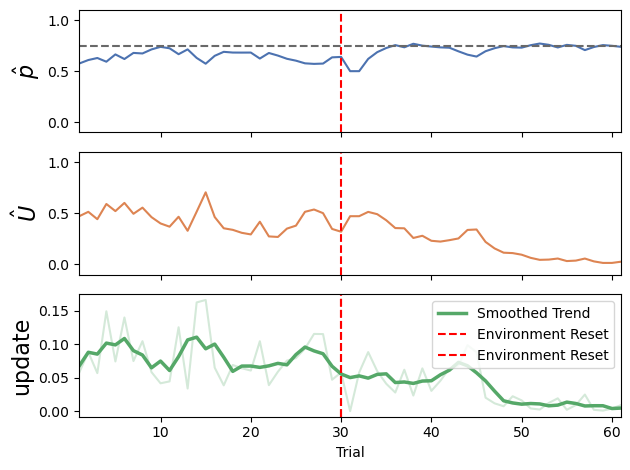

In [ ]:
p_hats = p_hats_mean
U_hats = U_hats_mean
PE_Uhats = PE_Uhat_mean
ground_truth = 0.75
# Manual plotting function
trials = np.arange(1, len(p_hats_mean)+1)

 # Get 3 colors for the 3 plots
blue, green, red = sns.color_palette("deep", n_colors=3)

#trials = np.arange(learner.data.size)
xlim = trials.min(), trials.max()

# Create 3 rows, sharing the X axis
f, (p_ax, I_ax, prod_ax) = plt.subplots(3, 1, sharex=True) #, **kwargs

# --- Plot 1: Probability (p_hat) ---
p_ax.plot(trials, p_hats, c=blue)
p_ax.axvline(x=force_reset_point, color='r', linestyle='--', label='Environment Reset')
#p_ax.scatter(trials, data, c=".25", alpha=.5, s=15)

if ground_truth is not None:
    p_ax.plot(trials, [ground_truth for t in trials], c="dimgray", ls="--")

p_ax.set_title("$\hat p$", size=16)
p_ax.set(xlim=xlim, ylim=(-.1, 1.1))

# --- Plot 2: Uncertainty (U_hat) ---
I_ax.plot(trials, U_hats, c=green)
I_ax.set_ylabel("$\hat U$", size=16)
I_ax.set(ylim=(-0.1, 1.1)) # Scaled 0-1
I_ax.axvline(x=force_reset_point, color='r', linestyle='--', label='Environment Reset')
import pandas as pd
smoothed_update = pd.Series(PE_Uhats).rolling(window=5, min_periods=1, center=True).mean()
prod_ax.plot(trials, smoothed_update, c=red,  linewidth=2.5, label='Smoothed Trend')
# --- Plot 3: Interaction (p * U) ---
prod_ax.plot(trials, PE_Uhats, alpha=0.25, c=red)
prod_ax.set_ylabel(r"update", size=16) #$\hat p ** \hat U$
prod_ax.set_xlabel("Trial") # Label only the bottom plot
prod_ax.axvline(x=force_reset_point, color='r', linestyle='--', label='Environment Reset')
#prod_ax.set(ylim=(-0.1, 1.1)) # Product of two 0-1 vars is 0-1


f.tight_layout()

plt.axvline(x=force_reset_point, color='r', linestyle='--', label='Environment Reset')
plt.legend()
plt.show()

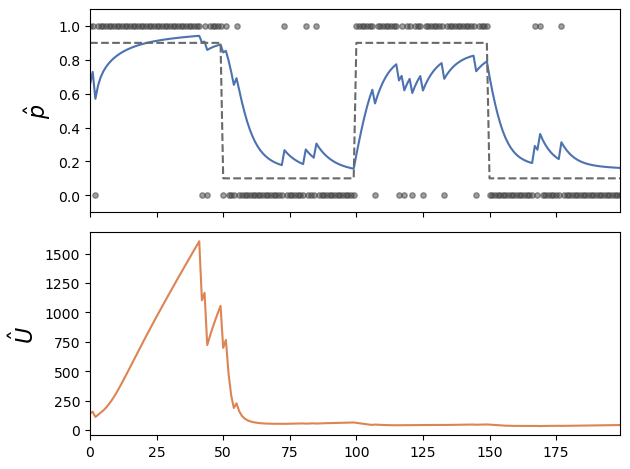

In [6]:

static_p = np.concatenate( [np.ones(50)* 0.9, np.ones(50)*0.1, np.ones(50)*0.9, np.ones(50)*0.1])
#static_p = np.ones(100)
# static_p[1:500] = 1.0
# static_p[500:750] = 0.0
# static_p[750:1000] = 0.5
static_y = stats.binom.rvs(1, static_p)
# static_y = np.concatenate([
#     np.random.binomial(1, 0.9, 50),
#     np.random.binomial(1, 0.1, 50),
#     np.random.binomial(1, 0.9, 50),
#     np.random.binomial(1, 0.1, 50)
# ])
learner.reset()
learner.fit(static_y)
learner.plot_history(ground_truth=static_p)

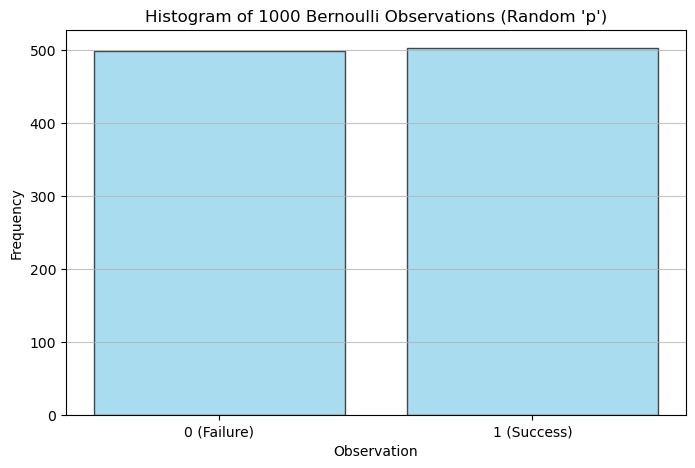

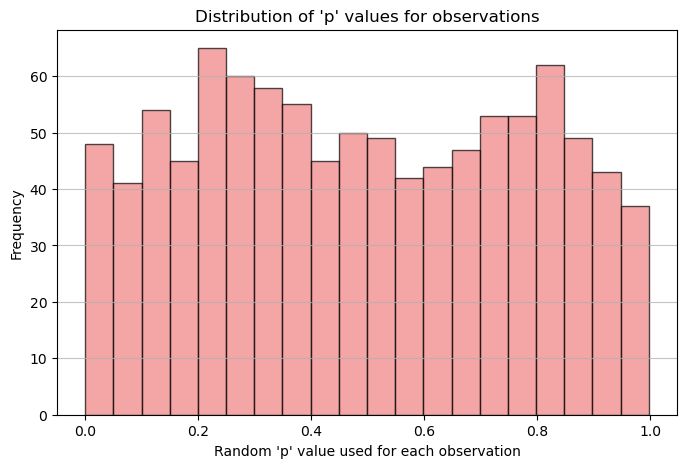

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_random_bernoulli_observations(num_observations):
    """
    Generates observations from a Bernoulli distribution where 'p' is
    randomly chosen between 0 and 1 for each observation.

    Args:
        num_observations (int): The number of observations to generate.

    Returns:
        numpy.ndarray: An array of Bernoulli observations (0s and 1s).
        numpy.ndarray: An array of the 'p' values used for each observation.
    """
    observations = np.zeros(num_observations, dtype=int)
    p_values = np.zeros(num_observations)

    for i in range(num_observations):
        # Randomly choose p for each observation from a uniform distribution [0, 1]
        p = np.random.uniform(0, 1)
        p_values[i] = p

        # Generate a Bernoulli observation
        observations[i] = np.random.binomial(n=1, p=p)

    return observations, p_values

# --- Parameters ---
NUM_OBSERVATIONS = 1000  # Number of data points to generate

# --- Generate observations ---
data, p_values_used = generate_random_bernoulli_observations(NUM_OBSERVATIONS)

# --- Plotting the histogram of observations ---
plt.figure(figsize=(8, 5))
plt.hist(data, bins=[-0.5, 0.5, 1.5], rwidth=0.8, color='skyblue', edgecolor='black', alpha=0.7)
plt.xticks([0, 1], ['0 (Failure)', '1 (Success)'])
plt.xlabel("Observation")
plt.ylabel("Frequency")
plt.title(f"Histogram of {NUM_OBSERVATIONS} Bernoulli Observations (Random 'p')")
plt.grid(axis='y', alpha=0.75)
plt.show()

# You can also look at the distribution of p values that were used
plt.figure(figsize=(8, 5))
plt.hist(p_values_used, bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel("Random 'p' value used for each observation")
plt.ylabel("Frequency")
plt.title("Distribution of 'p' values for observations")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# with mpl.rc_context({"font.size": 16}):
#     learner.show_model()

AttributeError: module 'daft' has no attribute 'PGM'

In [11]:
%timeit optlearner.ProbabilityLearner()

4.23 s ± 61 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


900 μs ± 52 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
def plot_slices(grid, joint, cmap, step=2, var=""):
    pal = sns.blend_palette(sns.mpl_palette(cmap, 6), as_cmap=True)
    f, axes = plt.subplots(4, 4, figsize=(7, 7), sharex=True, sharey=True)
    xx, yy = np.meshgrid(grid, grid)
    for k, ax in zip(np.arange(learner._I_size) * step, axes.flat):
        ax.contour(xx, yy, joint[:, :, k], cmap=pal, vmin=joint.min(), vmax=joint.max())
    if var:
        for ax in axes[-1, :]:
            ax.set_xlabel(str(var), size=14)
        for ax in axes[:, 0]:
            ax.set_ylabel(str(var), size=14)
    plt.tight_layout()

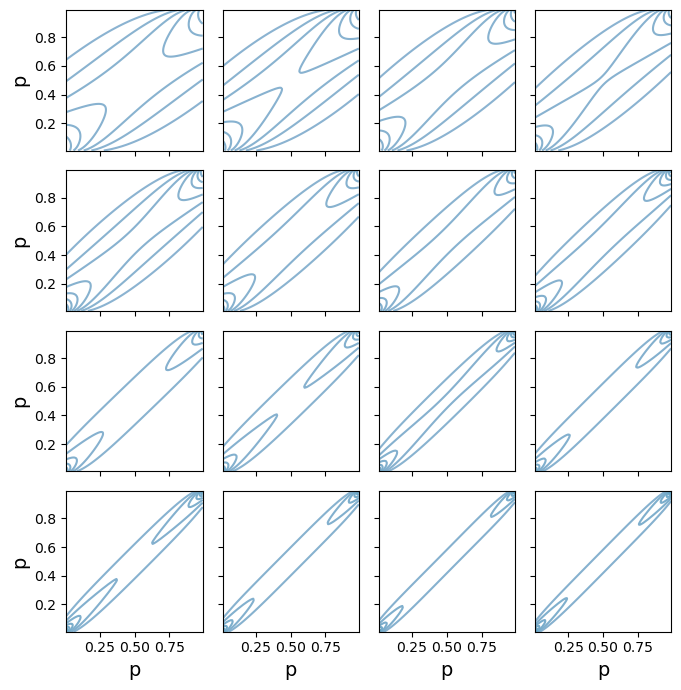

In [ ]:
plot_slices(learner.p_grid, learner._p_trans, "PuBuGn_d", var="p")

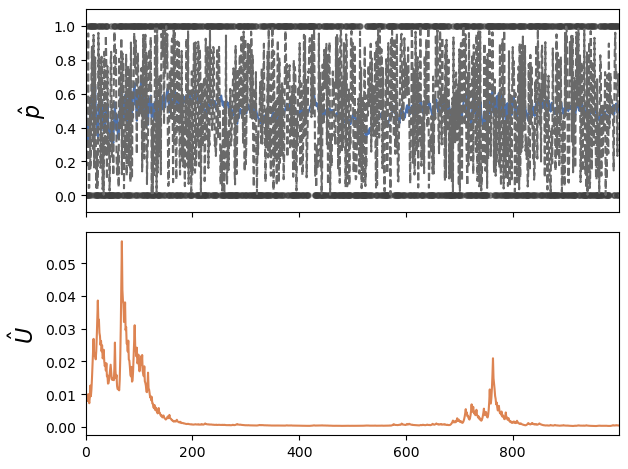

In [6]:
learner = optlearner.ProbabilityLearner()
static_p = np.random.rand(1000)
#static_p = np.ones(100)
# static_p[1:500] = 1.0
# static_p[500:750] = 0.0
# static_p[750:1000] = 0.5
static_y = stats.binom.rvs(1, static_p)
learner.reset()
learner.fit(static_y)
learner.plot_history(ground_truth=static_p)

AttributeError: Axes.set() got an unexpected keyword argument 'axis_bgcolor'

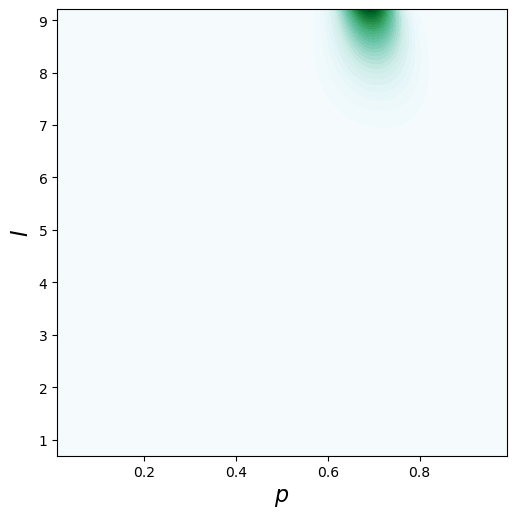

In [ ]:
learner.plot_joint()

In [ ]:
moving_p = np.repeat([.75, .25, .75, .25, .75, .25], 100)
moving_y= stats.binom.rvs(1, moving_p)

In [ ]:
learner.reset()
learner.fit(moving_y)

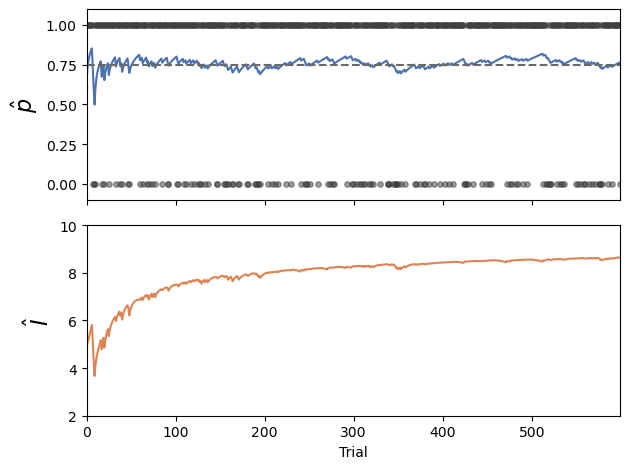

In [ ]:
learner.plot_history(ground_truth=moving_p)

AttributeError: module 'seaborn' has no attribute 'axlabel'

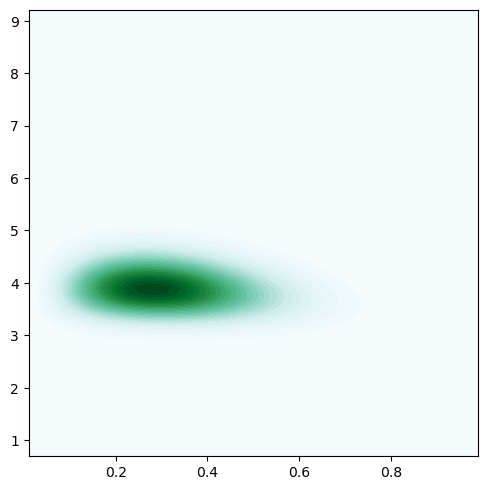

In [ ]:
learner.plot_joint()

In [ ]:
metavol_p = np.repeat([.75, .75, .75, .25, .75, .25], 100)
metavol_y= stats.binom.rvs(1, metavol_p)
     

In [ ]:
learner.reset()
learner.fit(metavol_y)

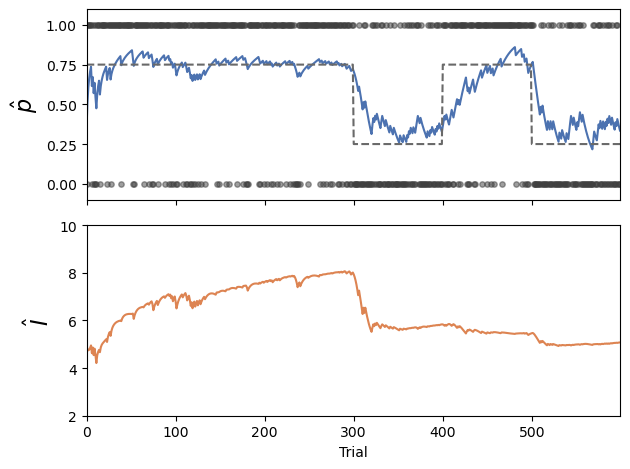

In [ ]:
learner.plot_history(ground_truth=metavol_p)

AttributeError: module 'seaborn' has no attribute 'axlabel'

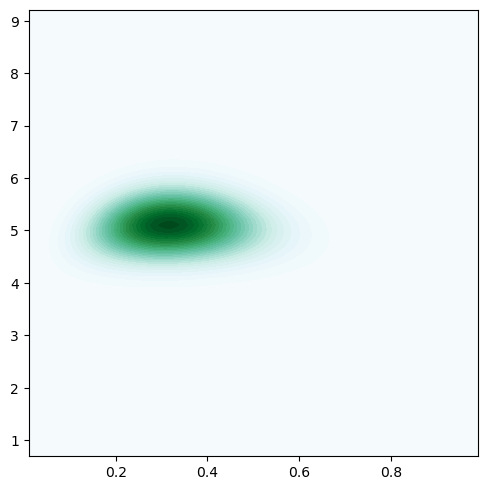

In [ ]:
learner.plot_joint()

In [ ]:
x = np.linspace(0, 60, 600)
sin_p = (np.sin(x / 3) + 1.5) / 3
sin_y = stats.binom.rvs(1, sin_p)

In [ ]:
learner.reset()
learner.fit(sin_y)

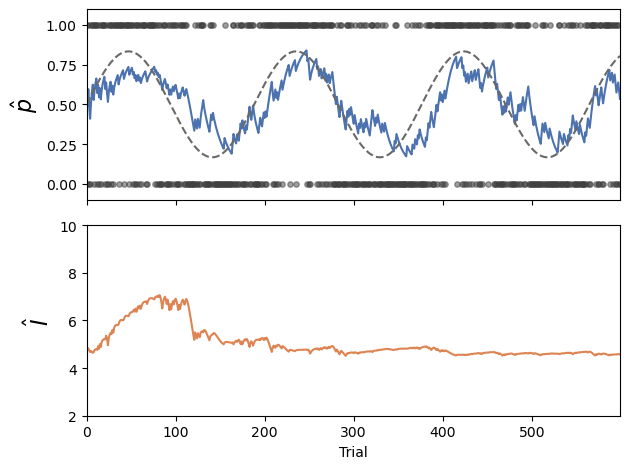

In [ ]:
learner.plot_history(ground_truth=sin_p)

AttributeError: module 'seaborn' has no attribute 'axlabel'

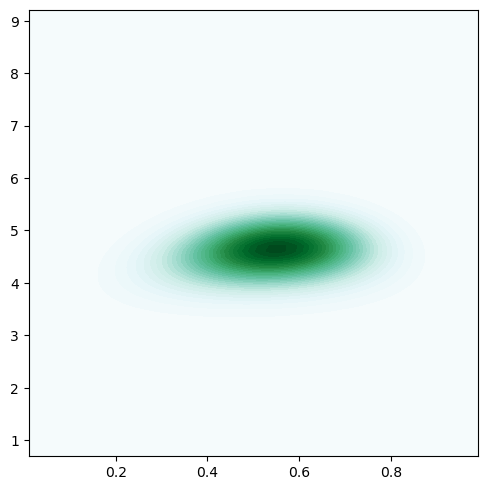

In [ ]:
learner.plot_joint()